import necessary libraries

In [1]:
import pandas as pd
import numpy as np

Load raw dataset

In [2]:
file = r"C:\Users\Lenovo\OneDrive\Documents\DataSprint\data\DataWave.csv"

df = pd.read_csv(file)


Inspect dataset


In [3]:
df.isnull().sum()

df.info()
df.describe()
df.head()
df.tail()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       695 non-null    object 
 1   country                       705 non-null    object 
 2   age                           705 non-null    int64  
 3   gender                        626 non-null    object 
 4   subscription_type             705 non-null    object 
 5   avg_listening_hours_per_week  705 non-null    float64
 6   total_songs_played            705 non-null    int64  
 7   skip_rate                     705 non-null    object 
 8   satisfaction_score            661 non-null    float64
 9   churned                       705 non-null    object 
 10  monthly_fee                   672 non-null    object 
 11  join_date                     705 non-null    object 
dtypes: float64(2), int64(2), object(8)
memory usage: 66.2+ KB


Index(['user_id', 'country', 'age', 'gender', 'subscription_type',
       'avg_listening_hours_per_week', 'total_songs_played', 'skip_rate',
       'satisfaction_score', 'churned', 'monthly_fee', 'join_date'],
      dtype='object')

cleaning user_id

In [4]:
df['user_id'].isnull().sum()
df = df.drop_duplicates(subset=['user_id'])

df= df.dropna(subset=['user_id'])


Convert all categorical text column to lower case and strip whitespaces. These are for the rows of each their respective columns. Ensure column is treated as text with the help of .astype(str).

In [5]:
cat_cols = ['country', 'gender', 'subscription_type', 'churned']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

Cleaning gender values

In [6]:
df['gender'] = df['gender'].replace({
    'm': 'male',
    'f': 'female',
    'femle' : 'female',
    'female ': 'female',
    'others': 'other',
    'other ': 'other',
    'prefer not to say': 'unknown',
    'nan': np.nan
})

Cleaning churned columns. Convert yes/no or text to 0/1 integer  [user left => 1, user stayed => 0]

In [7]:
mapping = {
    'yes': 1, 'y': 1, '1': 1, 'true': 1,
    'no': 0, 'n': 0, '0': 0, 'false': 0
}

df['churned'] = (
    df['churned']
    .astype(str).str.strip().str.lower()
    .map(mapping)
)


# df['churned'].mean()   # Finding the mean of churned

Cleaning(Fix) Subscription Type

In [8]:
df['subscription_type'] = df['subscription_type'].replace({
    'premuim': 'premium',
    'premum': 'premium',
    'free trial': 'free',
    'fam': 'family',
    'stud': 'student',
    'studnt': 'student'
})

Cleaning country

In [9]:
df['country'] = df['country'].replace({
    'u.k.': 'United kingdom',
    'uk': 'United Kingdom',
    'U.K': ' United Kingdom',
    'united kingdom': 'United Kingdom',
    'United kingdom': 'United Kingdom',
    'ind': 'India',
    'india': 'India',
    'usa': 'United States',
    'us': 'United States',
    'nepal': 'Nepal',
    'nigeria': 'Nigeria',
    'ghana': 'Ghana',
    'kenya': 'Kenya',
    'brazil': 'Brazil',
    'south africa': 'South Africa'
})

Clean numeric columns. Convert invalid text like "ten" to NaN

In [10]:
num_cols = ['age', 'avg_listening_hours_per_week', 'total_songs_played', 'skip_rate', 'satisfaction_score', 'monthly_fee']

for cols in num_cols:
    df[cols] = pd.to_numeric(df[cols], errors='coerce')   # convert invalid values to NaN)

CLEAN join_date. Convert to datetime.

In [11]:
df['join_date'] = pd.to_datetime(df['join_date'], format='%m/%d/%Y', errors='coerce')
# df['join_date'].isnull().sum()

Checking Missing values

In [12]:
# df.isnull().sum()

IMPUTE MISSING VALUES PROPERLY [Fill in the missing data in the correct or appropriate way.]
1. Gender (leave as NaN or fill with "unknown"). [fillna means to fill in missing values]

In [13]:
df['gender'] = df['gender'].fillna('unknown')

2. When analyzing the skip rate, it's important to use the median rather than the mean. This is because the skip rate data is often skewed, meaning it can have outliers that disproportionately affect the average. The median provides a more accurate representation of the typical skip rate in such cases.

In [14]:
df['skip_rate'] = df['skip_rate'].fillna(df["skip_rate"].median())

3. Fill missing monthly fee values using the median value specific to each subscription type not the overall median.

In [15]:
df['monthly_fee'] = (
    df.groupby('subscription_type')['monthly_fee'].transform(lambda x: x.fillna(x.median()))
    )

4. Fill missing values for join_date

In [16]:
df['join_date'] = df['join_date'].fillna(df['join_date'].mode()[0])

Remove or fix numeric outliers:
1. skip_rate must be between 0 and 1 

In [17]:
df = df[(df['skip_rate'] >= 0) & (df['skip_rate'] <= 1)]

2. Age should be between 10 and 100

In [18]:
df = df[(df['age'] >= 10) & (df['age'] <= 100)]

3. Max listening hours per week = 168 (24*7)

In [19]:
df = df[df['avg_listening_hours_per_week'] <= 168]   

4. Satisfaction must be between 1 and 10

In [20]:
df = df[(df['satisfaction_score'] >= 1) & (df['satisfaction_score'] <= 10)]

5. Songs played cannot be negative + cap unrealistic values

In [21]:
df = df[df['total_songs_played'] >= 0]
df = df[df['total_songs_played'] < df['total_songs_played'].quantile(0.999)]

6.  Monthly fee cannot be negative or extremely high

In [22]:
df = df[df['monthly_fee'] >= 0]
df = df[df['monthly_fee'] < df['monthly_fee'].quantile(0.999)]

Reset index after removing rows

In [23]:
df = df.reset_index(drop=True)

FINAL MISSING VALUE CHECK

In [24]:
print("Final missing values:")
print(df.isnull().sum())
print(df.describe())
print(df.info())

Final missing values:
user_id                         0
country                         0
age                             0
gender                          0
subscription_type               0
avg_listening_hours_per_week    0
total_songs_played              0
skip_rate                       0
satisfaction_score              0
churned                         0
monthly_fee                     0
join_date                       0
dtype: int64
              age  avg_listening_hours_per_week  total_songs_played  \
count  581.000000                    581.000000          581.000000   
mean    38.407917                     10.204647          499.304647   
min     13.000000                      0.100000          440.000000   
25%     25.000000                      6.800000          484.000000   
50%     38.000000                     10.200000          499.000000   
75%     51.000000                     13.300000          514.000000   
max     64.000000                     23.700000          566

cleaned dataset

In [25]:
cleaned_dataset = r"C:\Users\Lenovo\OneDrive\Documents\DataSprint\data\cleaned_DataWave.csv"
df.to_csv(cleaned_dataset, index=False)

df = pd.read_csv(cleaned_dataset)

UNIVARIATE ANALYSIS (Single Variable at a Time)
1. Weekly listening hours distribution [Summary statistics of average listening hours per week]

In [26]:
df['avg_listening_hours_per_week'].describe() 

count    581.000000
mean      10.204647
std        4.838402
min        0.100000
25%        6.800000
50%       10.200000
75%       13.300000
max       23.700000
Name: avg_listening_hours_per_week, dtype: float64

2. Satisfaction Score Description

In [27]:
df['satisfaction_score'].describe()

count    581.000000
mean       3.141136
std        1.186437
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: satisfaction_score, dtype: float64

3. Counting the number of each subscription type

In [28]:
df['subscription_type'].value_counts()   

subscription_type
family     180
student    163
premium    152
free        86
Name: count, dtype: int64

4. Counting the number of each country

In [29]:
df['country'].value_counts()

country
United Kingdom    109
India              96
United States      68
Kenya              55
Nigeria            53
Ghana              50
South Africa       46
Brazil             36
Nepal              34
United kingdom     34
Name: count, dtype: int64

5. Counting the number of each country

In [30]:
df['gender'].value_counts()

gender
female     222
male       221
unknown     69
other       69
Name: count, dtype: int64

Relationship insights [Analysis part] [BIVARIATE ANALYSIS (Two Variables Relationship)]
1. Does churn differ by subscription type?(Churn rate by subscription type)

In [31]:
df.groupby('subscription_type')['churned'].mean().sort_values(ascending=False)

subscription_type
family     0.316667
premium    0.296053
student    0.294479
free       0.279070
Name: churned, dtype: float64

2. Do heavy listeners churn less? (Listening hours: churned vs active). Low hours = more churn, High hours = more engagement

In [32]:
df.groupby('churned')['avg_listening_hours_per_week'].mean()

churned
0    10.266093
1    10.060920
Name: avg_listening_hours_per_week, dtype: float64

3. Does satisfaction predict churn?(Satisfaction score: churned vs active). If churned users have lower scores then obvious red flag for company. 


In [33]:
df.groupby('churned')['satisfaction_score'].mean()

churned
0    3.110565
1    3.212644
Name: satisfaction_score, dtype: float64

4. Which country or region has highest churn? (Top 10 countries with highest churn)

In [34]:
df.groupby('country')['churned'].mean().sort_values(ascending=False).head(10)

country
Brazil            0.361111
Nigeria           0.358491
Ghana             0.340000
Kenya             0.327273
United Kingdom    0.321101
South Africa      0.304348
United kingdom    0.294118
India             0.260417
United States     0.235294
Nepal             0.205882
Name: churned, dtype: float64

5. Satisfaction by subscription type

In [35]:
df.groupby('subscription_type')['satisfaction_score'].mean().sort_values()

subscription_type
free       3.069767
student    3.098160
family     3.155556
premium    3.210526
Name: satisfaction_score, dtype: float64

6. Average listening hours by subscription type

In [36]:
df.groupby('subscription_type')['avg_listening_hours_per_week'].mean().sort_values()

subscription_type
family      9.943333
free       10.027907
premium    10.071711
student    10.710429
Name: avg_listening_hours_per_week, dtype: float64

7. Churn rate by age group.
pd.cut takes a continuous variable (like age) and splits it into buckets (bins).
EG:-
age_group
(10, 20]     0.08
(20, 30]     0.12
(30, 40]     0.15
(40, 50]     0.09
(50, 60]     0.07
(60, 100]    0.20
Name: churned, dtype: float64


In [37]:
df['age_group'] = pd.cut(df['age'], bins=[10,20,30,40,50,60,100])
df.groupby('age_group', observed=False)['churned'].mean()


age_group
(10, 20]     0.284211
(20, 30]     0.349057
(30, 40]     0.309735
(40, 50]     0.252101
(50, 60]     0.333333
(60, 100]    0.244898
Name: churned, dtype: float64

8. Engagement vs churn (songs played)

In [38]:
df.groupby('churned')['total_songs_played'].mean()

churned
0    498.855037
1    500.356322
Name: total_songs_played, dtype: float64

[MULTIVARIATE ANALYSIS (3 or More Variables Together)]

1. Correlation between numeric columns (to see drivers of churn). 

Correlation means How Two Things Move Together.
Imagine two things: X and Y (like age and monthly_charges).
Correlation tells you: When X goes up, does Y tend to go up as well? Or go down? Or not change in any clear way?

+1 → Perfect positive correlation, –1 → Perfect negative correlation, 0 → No clear linear relationship

For eg:-
It checks correlation between:-
Correlation between churned and age
Correlation between churned and monthly charges

In [39]:
df.corr(numeric_only=True)['churned'].sort_values(ascending=False)

churned                         1.000000
satisfaction_score              0.039442
total_songs_played              0.029878
monthly_fee                    -0.011022
avg_listening_hours_per_week   -0.019440
age                            -0.027391
skip_rate                      -0.066314
Name: churned, dtype: float64

Visualization
1. Visualize churn rate by subscription type

<Axes: xlabel='subscription_type'>

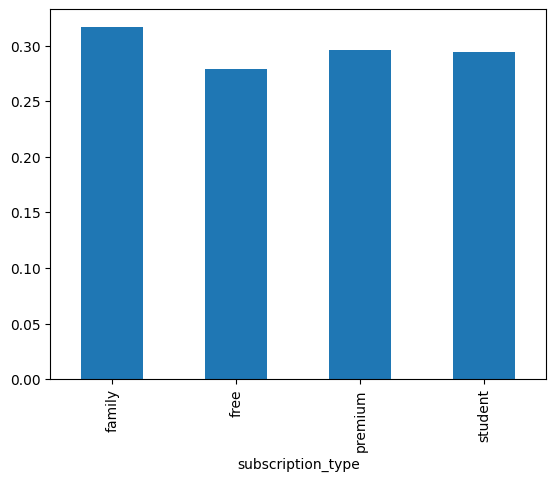

In [40]:
df.groupby('subscription_type')['churned'].mean().plot(kind='bar')

2. Visualize distribution of satisfaction score

<Axes: ylabel='Frequency'>

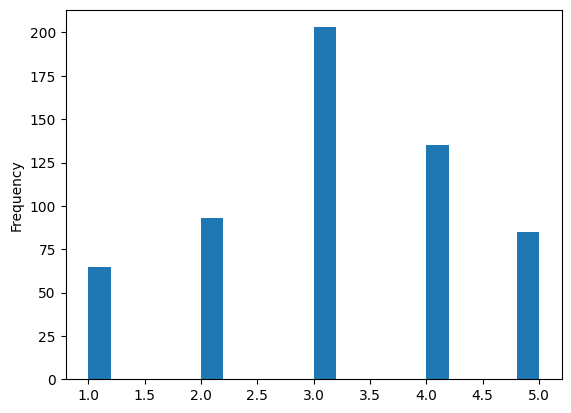

In [41]:
df['satisfaction_score'].plot(kind='hist', bins=20)

3. Boxplot: Listening hours by churn

<Axes: title={'center': 'avg_listening_hours_per_week'}, xlabel='churned'>

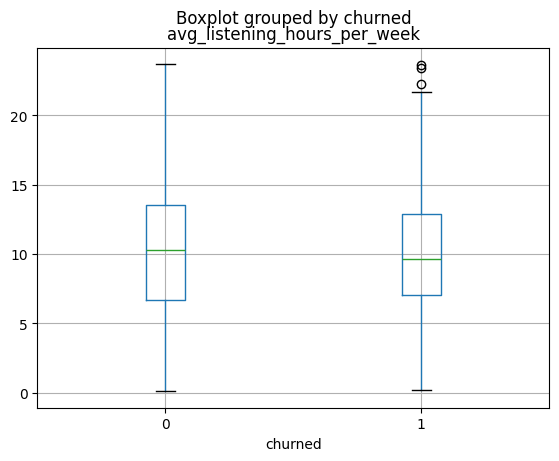

In [42]:
df.boxplot(column='avg_listening_hours_per_week', by='churned')

4. Heatmap for numeric correlation

<Axes: >

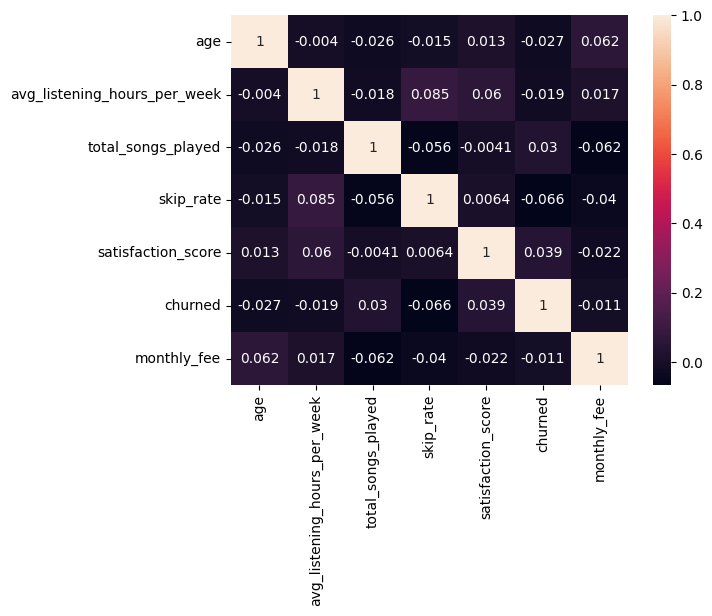

In [43]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True)

5. Country-wise churn bar plot (Top 10)

<Axes: ylabel='country'>

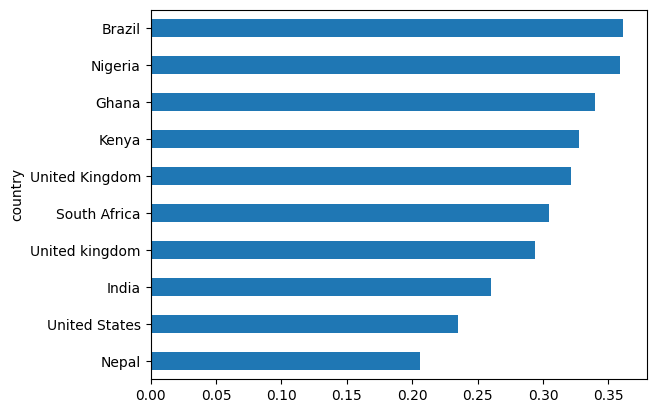

In [44]:
df.groupby('country')['churned'].mean().sort_values().tail(10).plot(kind='barh')

6. Scatter: Satisfaction vs Listening Hours

<Axes: xlabel='satisfaction_score', ylabel='avg_listening_hours_per_week'>

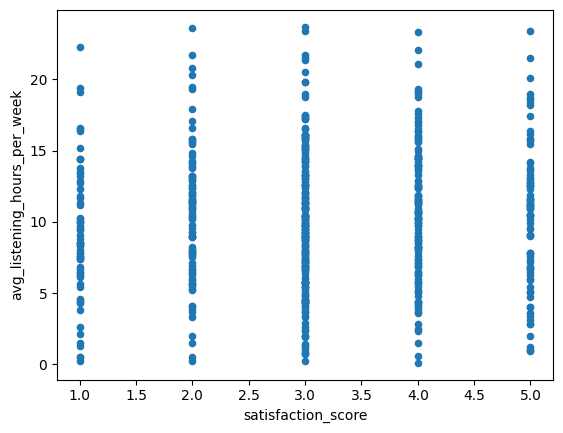

In [45]:
df.plot(kind='scatter', x='satisfaction_score', y='avg_listening_hours_per_week')

7. Create churn summary table

In [46]:
df.groupby('churned').mean(numeric_only=True)

,age,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,monthly_fee
churned,,,,,,
0,38.678133,10.266093,498.855037,0.191155,3.110565,6.965921
1,37.775862,10.060920,500.356322,0.186782,3.212644,6.883391


Build a Churn Prediction Model (Machine Learning)
1. Select the useful columns for modeling

In [47]:
features = [
    'age',
    'gender',
    'subscription_type',
    'avg_listening_hours_per_week',
    'total_songs_played',
    'skip_rate',
    'satisfaction_score',
    'monthly_fee',
    'country'
]

X = df[features]
y = df['churned']


2. Convert all categorical columns into numbers (One-Hot Encoding)

In [48]:
X = pd.get_dummies(X, drop_first=True)

3. Split data into Train and Test sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)